In [33]:
import sys
import os

# Forzamos a que Python use UTF-8 para leer archivos si estamos en Windows
os.environ["PYTHONIOENCODING"] = "utf-8"

%load_ext autoreload
%autoreload 2

import pickle
import pandas as pd
import numpy as np
from preprocesado import preprocesado, seleccion_caracteristicas_check, seleccion_caracteristicas
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier   # Asegurarse de tener xgboost instalado: pip install xgboost
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone
import scipy.stats as stats
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier # Asegurarse de tener catboost instalado: pip install catboost
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier # Asegurarse de tener lightgbm instalado: pip install lightgbm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Cargamos datos
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [3]:
# Ordenar por fecha
train = train.sort_values(by="Data_Solicitude").reset_index(drop=True)
test = test.sort_values(by="Data_Solicitude").reset_index(drop=True)
ids_test_final = test['ID_Cliente'].copy()

# Preprocesamos datos
train_tree_pre, train_linear_pre, test_tree_pre, test_linear_pre = preprocesado(train, test)

X_train_tree = train_tree_pre.drop(columns=['Target_Risco'])
y_train_tree = train_tree_pre['Target_Risco']   
X_train_linear = train_linear_pre.drop(columns=['Target_Risco'])
y_train_linear = train_linear_pre['Target_Risco']

In [4]:
print(len(ids_test_final), len(test_tree_pre), len(test_linear_pre))

6250 6250 6250


In [5]:
# Preprocesado
X_train_tree.head()


,num__Idade,num__Lonxitude_Nome,num__Num_Fillos,num__Anos_Emprego,num__Ingresos_Anuais,num__Tempo_Web_Minutos,num__Distancia_Oficina_Km,num__Patrimonio_Total,num__Debeda_Total,num__Numero_Tarxetas,...,num__Saldo_Medio_3M,num__Variacion_Saldo_6M,num__Fondo_Emerxencia_Meses,num__Indice_Estres_Financeiro,cat__Profesion,cat__Tipo_Dispositivo,cat__Dia_Solicitude,cat__Codigo_Postal,bin__Subscricion_Email,bin__Historial_Impagos
0,27.0,17.0,2.0,2.1,7660.67,45.0,17.300000,38804.64,2409.78,3.0,...,489.85,-0.091,8.11,0.234,1.0,0.0,5.0,12.0,0.0,0.0
1,38.0,33.0,0.0,0.0,3567.82,40.2,14.391431,54812.78,209.21,2.0,...,217.15,-0.030,24.00,0.171,2.0,4.0,2.0,9.0,0.0,0.0
2,28.0,19.0,1.0,2.7,34619.07,11.7,12.600000,143747.90,536.50,0.0,...,4304.93,-0.127,24.00,0.187,0.0,3.0,5.0,11.0,0.0,0.0
3,28.0,20.0,3.0,3.3,20970.54,21.6,43.200000,36753.12,2674.20,3.0,...,2031.62,-0.005,24.00,0.265,1.0,3.0,5.0,8.0,0.0,0.0
4,34.0,20.0,0.0,4.1,49197.94,33.5,48.900000,243397.87,9749.81,3.0,...,5592.09,-0.007,24.00,0.102,0.0,3.0,2.0,3.0,0.0,0.0


In [6]:
# Validación cruzada estratificada e TimeSeriesSplit

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tscv = TimeSeriesSplit(n_splits=5)

scorer = make_scorer(f1_score, average='macro')  # macro porque tienes 4 clases

# Seleccion caracteristicas para versión 1 stacking
# ===== Stacking =====
X_train_stacking, selector_stacking, _ = seleccion_caracteristicas(
        X_train_linear, y_train_linear,
        metodo='kbest',
        k=25
    )

### Función de guardado y/o carga de modelos

In [7]:
def entrenar_o_cargar(modelo, X_train, y_train, nombre_modelo_archivo):
    #Cargar el modelo si existe
    if os.path.exists(nombre_modelo_archivo):
        with open(nombre_modelo_archivo, "rb") as f:
            modelo = pickle.load(f)
    #Si no existe, entrenar el modelo y guardarlo
    else:
        modelo.fit(X_train, y_train)
        with open(nombre_modelo_archivo, "wb") as f:
            pickle.dump(modelo, f)
    
    return modelo

## Modelos basados en árboles de decisión

In [8]:
# ── Random Forest con TimeSeriesSplit ─────────────────────────────────────────────────────────────
param_grid_rf = {
    'n_estimators':      [400, 500, 600, 700],
    'max_depth':         [None, 20, 30, 40],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf':  [3, 4, 5, 6],
    'max_features':      [0.4, 0.5, 0.6],
    'class_weight':      ['balanced'],
}

search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=100,           # prueba 50 combinaciones aleatorias
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_rf = entrenar_o_cargar(search_rf, X_train_tree, y_train_tree, "models/search_rf.pkl")
print("Mejores params RF:", search_rf.best_params_)
print("Mejor F1 RF:", search_rf.best_score_)

Mejores params RF: {'n_estimators': 600, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 20, 'class_weight': 'balanced'}
Mejor F1 RF: 0.7718813932136541


In [9]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
# TimeSeriesSplit con random search de hiperparámetros

param_grid_xgb = {
    'n_estimators':     [150, 200, 250, 300],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.03, 0.05, 0.07, 0.1],
    'subsample':        [0.65, 0.7, 0.75, 0.8],
    'colsample_bytree': [0.75, 0.8, 0.85, 0.9],
    'min_child_weight': [2, 3, 4, 5],
    'gamma':            [0.2, 0.3, 0.4, 0.5],
    'reg_alpha':        [0.3, 0.5, 0.7],
    'reg_lambda':       [1.0, 1.5, 2.0],
}

search_xgb = RandomizedSearchCV(
    XGBClassifier(objective="multi:softmax", num_class=4,
                  random_state=42, n_jobs=-1),
    param_distributions=param_grid_xgb,
    n_iter=100,
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_xgb =  entrenar_o_cargar(search_xgb, X_train_tree, y_train_tree, "models/search_xgb.pkl")
print("Mejores params XGB:", search_xgb.best_params_)
print("Mejor F1 XGB:", search_xgb.best_score_)

Mejores params XGB: {'subsample': 0.65, 'reg_lambda': 2.0, 'reg_alpha': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.75}
Mejor F1 XGB: 0.7661453325071766


In [10]:
# ── CatBoost con TimeSeriesSplit ──────────────────────────────────────────────
X_train_tree_cb = X_train_tree.astype("float32")

param_grid_catboost = {
    'iterations':        [200, 300, 500, 700],
    'depth':             [4, 5, 6, 7, 8],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg':       [1, 3, 5, 7, 9],       # regularización L2
    'bagging_temperature':[0, 0.5, 1, 2],        # aleatoriedad del bagging
    'border_count':      [32, 64, 128],           # bins para features numéricas
    'class_weights':     [{0:1,1:1,2:1,3:1},     # sin peso
                          {0:1,1:2,2:3,3:4}],    # más peso a clases de alto riesgo
}

search_catboost = RandomizedSearchCV(
    CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='TotalF1',
        random_state=42,
        verbose=0           # silenciar output interno de CatBoost
    ),
    param_distributions=param_grid_catboost,
    n_iter=50,              # CatBoost es lento, menos iteraciones
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_catboost = entrenar_o_cargar(search_catboost, X_train_tree_cb, y_train_tree, "models/search_catboost.pkl")
print("Mejores params CatBoost:", search_catboost.best_params_)
print("Mejor F1 CatBoost:",       search_catboost.best_score_)

Mejores params CatBoost: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 6, 'class_weights': {0: 1, 1: 2, 2: 3, 3: 4}, 'border_count': 32, 'bagging_temperature': 0.5}
Mejor F1 CatBoost: 0.7834377347181645


In [11]:
# ── ExtraTrees con TimeSeriesSplit ────────────────────────────────────────────
param_grid_et = {
    'n_estimators':      [400, 500, 600, 700],
    'max_depth':         [None, 20, 30, 40],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf':  [3, 4, 5, 6],
    'max_features':      [0.4, 0.5, 0.6],
    'class_weight':      ['balanced'],
}

search_et = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_grid_et,
    n_iter=100,
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_et = entrenar_o_cargar(search_et, X_train_tree, y_train_tree, "models/search_et.pkl")
print("Mejores params ExtraTrees:", search_et.best_params_)
print("Mejor F1 ExtraTrees:",       search_et.best_score_)


Mejores params ExtraTrees: {'n_estimators': 600, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 0.6, 'max_depth': 40, 'class_weight': 'balanced'}
Mejor F1 ExtraTrees: 0.7723483834385879


In [12]:
# ── LightGBM con TimeSeriesSplit ──────────────────────────────────────────────
param_grid_lgbm = {
    'n_estimators':      [200, 300, 500, 700],
    'max_depth':         [4, 5, 6, 7, 8, -1],   # -1 = sin límite
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9],
    'min_child_samples': [10, 20, 30, 50],       # equivalente a min_child_weight en XGB
    'reg_alpha':         [0, 0.1, 0.5],          # L1
    'reg_lambda':        [1, 1.5, 2],            # L2
    'num_leaves':        [15, 31, 63, 127],      # parámetro clave de LightGBM
    'class_weight':      ['balanced', None],
}

search_lgbm = RandomizedSearchCV(
    LGBMClassifier(
        objective='multiclass',
        num_class=4,
        random_state=42,
        n_jobs=-1,
        verbose=-1          # silenciar output interno de LightGBM
    ),
    param_distributions=param_grid_lgbm,
    n_iter=100,
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_lgbm = entrenar_o_cargar(search_lgbm, X_train_tree, y_train_tree, "models/search_lgbm.pkl")
print("Mejores params LightGBM:", search_lgbm.best_params_)
print("Mejor F1 LightGBM:",       search_lgbm.best_score_)

Mejores params LightGBM: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8, 'class_weight': 'balanced'}
Mejor F1 LightGBM: 0.7735895083389577


### Separeción de los modelos con mejores parámetros

In [13]:
# Mejor combinación de hiperparámetros para cada modelo:

# Random Forest
rf_best = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=4,
    max_features=0.5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_best = entrenar_o_cargar(rf_best, X_train_tree, y_train_tree, "models/rf_best.pkl")

# XGBoost
xgb_best = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.3,   # aquí elige el mejor valor real entre 0.2, 0.3, 0.4, 0.5
    reg_alpha=0.3,
    reg_lambda=2.0,
    objective="multi:softprob",
    num_class=4,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)
xgb_best =  entrenar_o_cargar(xgb_best, X_train_tree, y_train_tree, "models/xgb_best.pkl")

#CatBoost
catboost_best = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    bagging_temperature=0.5,
    border_count=32,
    class_weights={0: 1, 1: 2, 2: 3, 3: 4},
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_state=42,
    verbose=0
)
catboost_best = entrenar_o_cargar(catboost_best, X_train_tree, y_train_tree, "models/catboost_best.pkl")

# ExtraTrees
et_best = ExtraTreesClassifier(
    n_estimators=600,
    max_depth=40,
    min_samples_split=3,
    min_samples_leaf=3,
    max_features=0.6,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
et_best = entrenar_o_cargar(et_best, X_train_tree, y_train_tree, "models/et_best.pkl")

# LightGBM
lgbm_best = LGBMClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.5,
    reg_lambda=1.5,
    num_leaves=15,
    class_weight="balanced",
    objective="multiclass",
    num_class=4,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_best = entrenar_o_cargar(lgbm_best, X_train_tree, y_train_tree, "models/lgbm_best.pkl")

#### Función para crear submits

In [14]:
def submit(model, filename, test_data):
    preds = model.predict(test_data)
    submission = pd.DataFrame({
        "ID_Cliente": ids_test_final, 
        "Target_Risco": preds
    })
    submission.to_csv(f"results/{filename}", index=False)
    print(f"Archivo {filename} creado con éxito.")


## Modelos lineales

### Entreno MLP

In [15]:

# ── 2. Grid de hiperparámetros (sin prefijo de pipeline) ─────────────────────
param_grid_mlp = {
    'hidden_layer_sizes': [
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (256, 128),
        (128, 64, 32),
        (256, 128, 64)
    ],
    'alpha':              [0.001, 0.01, 0.1],
    'learning_rate_init': [0.001],
    'max_iter':           [200, 300, 500],
    'early_stopping':     [True],
    'validation_fraction':[0.1],
    'batch_size':         [8, 16, 32],
    'activation':         ['relu', 'tanh'],
}

# ── 3. RandomizedSearchCV directamente sobre el modelo ───────────────────────
search_mlp = RandomizedSearchCV(
    MLPClassifier(solver='adam', random_state=42),
    param_distributions=param_grid_mlp,
    n_iter=50,
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_mlp = entrenar_o_cargar(search_mlp, X_train_stacking, y_train_linear, "models/search_mlp.pkl")
print("Mejores params MLP:", search_mlp.best_params_)
print("Mejor F1 MLP:",       search_mlp.best_score_)

Mejores params MLP: {'validation_fraction': 0.1, 'max_iter': 200, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64, 32), 'early_stopping': True, 'batch_size': 8, 'alpha': 0.01, 'activation': 'relu'}
Mejor F1 MLP: 0.7649607109418899


In [16]:
# Modelo con mejores hiperparámetros
mlp_best = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    alpha=0.01,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    batch_size=8,
    activation='relu',
    solver='adam',
    random_state=42
)
mlp_best = entrenar_o_cargar(mlp_best, X_train_stacking, y_train_linear, "models/mlp_best.pkl")

### Entreno KNN

In [17]:
# ── 2. Grid de hiperparámetros ────────────────────────────────────────────
param_grid_knn = {
    'n_neighbors':  [3, 5, 7, 9, 11, 15, 21],
    'weights':      ['uniform', 'distance'],
    'metric':       ['euclidean', 'manhattan', 'minkowski'],
    'p':            [1, 2],
    'leaf_size':    [20, 30, 40],
}

# ── 3. RandomizedSearchCV ─────────────────────────────────────────────────
search_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_grid_knn,
    n_iter=50,
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_knn = entrenar_o_cargar(search_knn, X_train_stacking, y_train_linear, "models/search_knn.pkl")


# Hai que mirar o da k
k = 8

print(f"k={k} | F1: {search_knn.best_score_:.4f} | params: {search_knn.best_params_}")

k=8 | F1: 0.6220 | params: {'weights': 'distance', 'p': 1, 'n_neighbors': 7, 'metric': 'manhattan', 'leaf_size': 40}


In [18]:
# RIP miña CPU, que aqui descansa

#submit(mejor_modelo_knn, f"submission_knn_prueba.csv", X_test_knn_final)

In [19]:
# Modelo con mejores hiperparámetros
# Seleccion de caracteristicas con k = 8
knn_best = KNeighborsClassifier(
    n_neighbors=21,
    weights="distance",
    metric="minkowski",
    p=1,
    leaf_size=30,
    n_jobs=-1
)
knn_best = entrenar_o_cargar(knn_best, X_train_stacking, y_train_linear, "models/knn_best.pkl")

### Entreno regresión logística

In [20]:

# ── 2. Grid de hiperparámetros ────────────────────────────────────────────────
param_grid_logres = {
    'C':            [0.001, 0.01, 0.1, 1, 10, 100],  # inverso de regularización
    'penalty':      ['l1', 'l2', 'elasticnet'],
    'l1_ratio':     [0.1, 0.3, 0.5, 0.7, 0.9],       # solo para elasticnet
    'solver':       ['saga'],                          # único solver compatible con l1+elasticnet
    'class_weight': ['balanced', None],
    'max_iter':     [500, 1000],
}

# ── 3. RandomizedSearchCV ─────────────────────────────────────────────────────
search_logres = RandomizedSearchCV(
    LogisticRegression(multi_class='multinomial', random_state=42),
    param_distributions=param_grid_logres,
    n_iter=75,
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_logres = entrenar_o_cargar(search_logres, X_train_stacking, y_train_linear, "models/search_logres.pkl")
print("Mejores params LogRes:", search_logres.best_params_)
print("Mejor F1 LogRes:",       search_logres.best_score_)

Mejores params LogRes: {'solver': 'saga', 'penalty': 'elasticnet', 'max_iter': 500, 'l1_ratio': 0.5, 'class_weight': None, 'C': 1}
Mejor F1 LogRes: 0.7290519973024258


In [21]:
# Modelo con mejores hiperparámetros
logres_best = LogisticRegression(
    C=1,
    penalty="elasticnet",
    l1_ratio=0.5,
    solver="saga",
    max_iter=500,
    class_weight=None,
    multi_class="multinomial",
    random_state=42,
    n_jobs=-1
)
logres_best = entrenar_o_cargar(logres_best, X_train_stacking, y_train_linear, "models/logres_best.pkl")

## CONSTRUCCION DE STACKING
#### Stacking de trees

In [22]:
from sklearn.base import BaseEstimator, ClassifierMixin
from catboost import CatBoostClassifier
import numpy as np

class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, **params):
        self.params = params
        self._model = CatBoostClassifier(**params)
        # Inicializamos classes_ como None o vacío
        self.classes_ = None

    def fit(self, X, y):
        # Es buena práctica reinicializar el modelo aquí
        self._model = CatBoostClassifier(**self.params)
        self._model.fit(X, y)
        
        # Extraemos las clases detectadas durante el entrenamiento
        self.classes_ = self._model.classes_
        # ------------------------------
        
        return self

    def predict(self, X):
        return self._model.predict(X).flatten().astype(int)

    def predict_proba(self, X):
        return self._model.predict_proba(X)

    def get_params(self, deep=True):
        return self.params

    def set_params(self, **params):
        # Actualizamos los parámetros internos y el modelo
        self.params.update(params)
        self._model.set_params(**self.params)
        return self

In [23]:
# ===== Stacking =====
best_catboost_params = search_catboost.best_params_

stack_model_trees = StackingClassifier(
    estimators=[
        ("rf",          search_rf.best_estimator_),
        ("xgb",         search_xgb.best_estimator_),
        ("catboost",    CatBoostWrapper(
                            loss_function='MultiClass',
                            eval_metric='TotalF1',
                            random_state=42,
                            verbose=0,
                            **best_catboost_params   # mejores params del tuning
                        )),
        ("extratrees",  search_et.best_estimator_),
        ("lightgbm",    search_lgbm.best_estimator_)
    ],
    final_estimator=LogisticRegression(
        C=0.1,
        multi_class='multinomial',
        solver='saga',
        class_weight='balanced',
        max_iter=1000
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

stack_model_trees = entrenar_o_cargar(stack_model_trees, X_train_tree, y_train_tree, "models/stack_model_trees.pkl")
submit(stack_model_trees, "stacking_all_trees_v1.csv", test_tree_pre)

Archivo stacking_all_trees_v1.csv creado con éxito.


#### Stacking global

In [24]:
# params: {'C': np.float64(10.0), 'penalty': np.str_('l2'), 'l1_ratio': np.float64(0.7), 'class_weight': 'balanced', 'max_iter': np.int64(1000)}
stack_model = StackingClassifier(
    estimators=[
        ("xgb", search_xgb.best_estimator_),
        ("mlp", search_mlp.best_estimator_),
        ("knn", search_knn.best_estimator_),
        ("logres", search_logres.best_estimator_)
    ],
    final_estimator=LogisticRegression(
        C=10.0,
        penalty='l2',
        class_weight='balanced',
        max_iter=2000),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

stack_model = entrenar_o_cargar(stack_model, X_train_stacking, y_train_linear, "models/stack_model.pkl")
test_stacking = test_linear_pre[X_train_linear.columns[selector_stacking.get_support()]]


In [25]:
#submit(stack_model, "stacking_global-meta-tunned-v1.1.csv", test_stacking)

In [26]:
# Evaluar con CV
scores = cross_val_score(
    stack_model, X_train_stacking, y_train_linear,
    cv=tscv, scoring=scorer, n_jobs=-1
)
score_medio = scores.mean()
print(f"F1: {score_medio:.4f}")

F1: 0.7821


### Entreno de meta modelo

In [37]:
from sklearn.model_selection import cross_val_score

param_grid_meta = {
    'C':            [0.001, 0.01, 0.1, 1, 10],
    'penalty':      ['l1', 'l2', 'elasticnet'],
    'l1_ratio':     [0.1, 0.3, 0.5, 0.7, 0.9],
    'class_weight': ['balanced', None],
    'max_iter':     [1000, 2000],
}

mejor_score_meta = -1
mejor_params_meta = None
mejor_stack = None

for _ in range(30):  # 30 combinaciones aleatorias
    # Samplear combinación aleatoria
    params = {k: np.random.choice(v) for k, v in param_grid_meta.items()}
    
    # elasticnet solo funciona con saga, l1/l2 funcionan con saga también
    meta = LogisticRegression(
        **params,
        solver='saga',
        multi_class='multinomial',
        random_state=42
    )

    # Construir stacking con este meta-learner
    stack = StackingClassifier(
        estimators=[
            ("xgb",    search_xgb.best_estimator_),
            ("mlp",    search_mlp.best_estimator_),
            ("knn",    search_knn.best_estimator_),
            ("logres", search_logres.best_estimator_)
        ],
        final_estimator=meta,
        stack_method="predict_proba",
        cv=5,
        n_jobs=-1
    )

    # Evaluar con CV
    scores = cross_val_score(
        stack, X_train_stacking, y_train_linear,
        cv=tscv, scoring=scorer, n_jobs=-1
    )
    score_medio = scores.mean()
    print(f"F1: {score_medio:.4f} | params: {params}")

    if score_medio > mejor_score_meta:
        mejor_score_meta  = score_medio
        mejor_params_meta = params
        mejor_stack       = stack

print(f"\n✅ Mejor F1 meta: {mejor_score_meta:.4f}")
print(f"✅ Mejores params meta: {mejor_params_meta}")

# ── Entrenar el mejor stacking con todo el train ──────────────────────────────
mejor_stack = entrenar_o_cargar(mejor_stack, X_train_stacking, y_train_linear, "models/mejor_stack_global.pkl")

# ── Submission ────────────────────────────────────────────────────────────────
test_stacking = test_linear_pre[X_train_linear.columns[selector_stacking.get_support()]]


F1: 0.7768 | params: {'C': np.float64(0.001), 'penalty': np.str_('l2'), 'l1_ratio': np.float64(0.9), 'class_weight': 'balanced', 'max_iter': np.int64(2000)}
F1: 0.7829 | params: {'C': np.float64(1.0), 'penalty': np.str_('elasticnet'), 'l1_ratio': np.float64(0.5), 'class_weight': 'balanced', 'max_iter': np.int64(1000)}
F1: 0.7794 | params: {'C': np.float64(1.0), 'penalty': np.str_('l1'), 'l1_ratio': np.float64(0.1), 'class_weight': 'balanced', 'max_iter': np.int64(2000)}
F1: 0.7787 | params: {'C': np.float64(10.0), 'penalty': np.str_('elasticnet'), 'l1_ratio': np.float64(0.7), 'class_weight': 'balanced', 'max_iter': np.int64(1000)}
F1: 0.7771 | params: {'C': np.float64(1.0), 'penalty': np.str_('elasticnet'), 'l1_ratio': np.float64(0.3), 'class_weight': None, 'max_iter': np.int64(1000)}
F1: 0.7768 | params: {'C': np.float64(0.001), 'penalty': np.str_('l2'), 'l1_ratio': np.float64(0.5), 'class_weight': 'balanced', 'max_iter': np.int64(2000)}
F1: 0.7815 | params: {'C': np.float64(1.0), 'pe

In [ ]:
#submit(mejor_stack, "stacking_global-meta-tunned-v1.csv", test_stacking)

In [38]:
print("Columnas test_tree_pre:", test_tree_pre.columns.tolist())
print("Columnas X_train_tree:", X_train_tree.columns.tolist())
print("Coinciden:", list(test_tree_pre.columns) == list(X_train_tree.columns))

Columnas test_tree_pre: ['num__Idade', 'num__Lonxitude_Nome', 'num__Num_Fillos', 'num__Anos_Emprego', 'num__Ingresos_Anuais', 'num__Tempo_Web_Minutos', 'num__Distancia_Oficina_Km', 'num__Patrimonio_Total', 'num__Debeda_Total', 'num__Numero_Tarxetas', 'num__Ratio_Deuda_Patrimonio', 'num__Ratio_Deuda_Ingresos', 'num__Tarjetas_Antiguedad', 'num__Capacidad_Ahorro', 'num__Utilizacion_Credito', 'num__Consultas_Risco_6M', 'num__Limite_Credito_Total', 'num__Cota_Mensual_Prestamos', 'num__Ratio_Cota_Ingresos', 'num__Prestamos_Activos', 'num__Antiguedade_Cliente_Anos', 'num__Saldo_Medio_3M', 'num__Variacion_Saldo_6M', 'num__Fondo_Emerxencia_Meses', 'num__Indice_Estres_Financeiro', 'cat__Profesion', 'cat__Tipo_Dispositivo', 'cat__Dia_Solicitude', 'cat__Codigo_Postal', 'bin__Subscricion_Email', 'bin__Historial_Impagos']
Columnas X_train_tree: ['num__Idade', 'num__Lonxitude_Nome', 'num__Num_Fillos', 'num__Anos_Emprego', 'num__Ingresos_Anuais', 'num__Tempo_Web_Minutos', 'num__Distancia_Oficina_Km', 

#### Entreno meta-modelo versión de trees

In [39]:
from sklearn.model_selection import cross_val_score

param_grid_meta = {
    'C':            [0.001, 0.01, 0.1, 1, 10],
    'penalty':      ['l1', 'l2', 'elasticnet'],
    'l1_ratio':     [0.1, 0.3, 0.5, 0.7, 0.9],
    'class_weight': ['balanced', None],
    'max_iter':     [1000, 2000],
}

mejor_score_meta = -1
mejor_params_meta = None
mejor_stack = None

for _ in range(20):  # 20 combinaciones aleatorias
    # Samplear combinación aleatoria
    params = {k: np.random.choice(v) for k, v in param_grid_meta.items()}
    
    # elasticnet solo funciona con saga, l1/l2 funcionan con saga también
    meta = LogisticRegression(
        **params,
        solver='saga',
        multi_class='multinomial',
        random_state=42
    )

    # Construir stacking con este meta-learner
    stack = StackingClassifier(
        estimators=[
            ("rf",    search_rf.best_estimator_),
            ("xgb",    search_xgb.best_estimator_)
        ],
        final_estimator=meta,
        stack_method="predict_proba",
        cv=5,
        n_jobs=-1
    )

    # Evaluar con CV
    scores = cross_val_score(
        stack, X_train_tree, y_train_tree,
        cv=tscv, scoring=scorer, n_jobs=-1
    )
    score_medio = scores.mean()
    print(f"F1: {score_medio:.4f} | params: {params}")

    if score_medio > mejor_score_meta:
        mejor_score_meta  = score_medio
        mejor_params_meta = params
        mejor_stack       = stack

print(f"\n✅ Mejor F1 meta: {mejor_score_meta:.4f}")
print(f"✅ Mejores params meta: {mejor_params_meta}")

# ── Entrenar el mejor stacking con todo el train ──────────────────────────────
mejor_stack = entrenar_o_cargar(mejor_stack, X_train_tree, y_train_tree, "models/mejor_stack_trees.pkl")


F1: 0.7740 | params: {'C': np.float64(1.0), 'penalty': np.str_('l1'), 'l1_ratio': np.float64(0.9), 'class_weight': 'balanced', 'max_iter': np.int64(1000)}
F1: 0.7700 | params: {'C': np.float64(0.1), 'penalty': np.str_('l1'), 'l1_ratio': np.float64(0.9), 'class_weight': None, 'max_iter': np.int64(2000)}
F1: 0.7795 | params: {'C': np.float64(10.0), 'penalty': np.str_('l2'), 'l1_ratio': np.float64(0.5), 'class_weight': 'balanced', 'max_iter': np.int64(1000)}
F1: 0.7722 | params: {'C': np.float64(10.0), 'penalty': np.str_('l1'), 'l1_ratio': np.float64(0.3), 'class_weight': 'balanced', 'max_iter': np.int64(1000)}
F1: 0.7371 | params: {'C': np.float64(0.001), 'penalty': np.str_('elasticnet'), 'l1_ratio': np.float64(0.3), 'class_weight': 'balanced', 'max_iter': np.int64(2000)}
F1: 0.7688 | params: {'C': np.float64(0.1), 'penalty': np.str_('elasticnet'), 'l1_ratio': np.float64(0.5), 'class_weight': None, 'max_iter': np.int64(2000)}
F1: 0.6713 | params: {'C': np.float64(0.01), 'penalty': np.str

c:\Users\lucia\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\lucia\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\lucia\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
#submit(mejor_stack, "stacking_trees-meta-tunned-v1.csv", test_tree_pre)

## Selección de características
No funciona porque el XGBoost ya hace selección interna y estoy cortando características que pueden serle útiles. 
Además estoy cogiendo parámetros óptimos para todas las características que para el espacio reducido puede no ser el óptimo

In [28]:
# Ver recuento de nulos por columna
nulos_por_columna = X_train_linear.isnull().sum()
print(nulos_por_columna[nulos_por_columna > 0])

# Ver qué filas tienen nulos (opcional)
filas_con_nulos = X_train_linear[X_train_linear.isnull().any(axis=1)]
print(f"\nTotal de filas con NaNs: {len(filas_con_nulos)}")

Series([], dtype: int64)

Total de filas con NaNs: 0


In [29]:
# Selección características (linear)
scores_kbest = seleccion_caracteristicas_check(X_train_linear, y_train_linear)
scores_kbest
# Mirar SelectFromModel de Scikit-Learn.

,Característica,Puntuación
26,num__Historial_Impagos,5114.593330
11,num__Ratio_Deuda_Ingresos,2525.426732
18,num__Ratio_Cota_Ingresos,2405.046976
15,num__Consultas_Risco_6M,2360.660646
47,cat__Codigo_Postal_15004,1960.031668
23,num__Fondo_Emerxencia_Meses,1477.635794
24,num__Indice_Estres_Financeiro,1116.018680
10,num__Ratio_Deuda_Patrimonio,651.336085
8,num__Debeda_Total,537.733264
19,num__Prestamos_Activos,501.324694


In [30]:
# Selección características (tree)
scores_kbest = seleccion_caracteristicas_check(X_train_tree, y_train_tree)
scores_kbest

,Característica,Puntuación
30,bin__Historial_Impagos,5114.593330
11,num__Ratio_Deuda_Ingresos,2525.426732
18,num__Ratio_Cota_Ingresos,2405.046976
15,num__Consultas_Risco_6M,2360.660646
23,num__Fondo_Emerxencia_Meses,1477.635794
24,num__Indice_Estres_Financeiro,1116.018680
10,num__Ratio_Deuda_Patrimonio,651.336085
8,num__Debeda_Total,537.733264
19,num__Prestamos_Activos,501.324694
17,num__Cota_Mensual_Prestamos,250.347379


### 

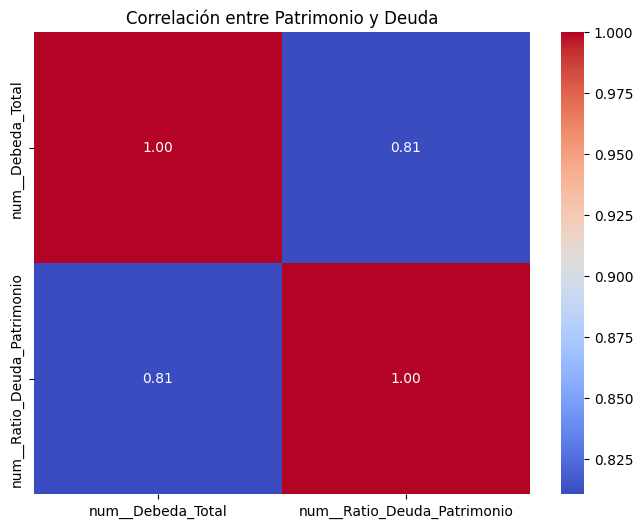

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Elegimos las variables sospechosas
cols_interes = ['num__Debeda_Total', 'num__Ratio_Deuda_Patrimonio']
matriz_corr = X_train_tree[cols_interes].corr()

# 2. Dibujamos el Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre Patrimonio y Deuda")
plt.show()

### Blending

In [35]:

# ── 1. Dividir train en dos partes fijas ─────────────────────────────────────
X_blend_train, X_blend_val, y_blend_train, y_blend_val = train_test_split(
    X_train_tree, y_train_tree,
    test_size=0.30,
    shuffle=False,    # ✅ shuffle=False respeta orden temporal
    random_state=42
)

# ── 2. Entrenar base learners en la parte 1 ───────────────────────────────────
rf_blend       = clone(rf_best).fit(X_blend_train, y_blend_train)
xgb_blend      = clone(xgb_best).fit(X_blend_train, y_blend_train)
lgbm_blend     = clone(lgbm_best).fit(X_blend_train, y_blend_train)
catboost_blend = CatBoostWrapper(**catboost_best.get_params()).fit(X_blend_train, y_blend_train)
et_blend       = clone(et_best).fit(X_blend_train, y_blend_train)

# ── 3. Generar predicciones sobre la parte 2 → input del meta-learner ─────────
# Dos versiones de meta modelo (solo preds, preds + features originales)
X_meta_train_preds = np.hstack([
    rf_blend.predict_proba(X_blend_val),        # (n_val, 4)
    xgb_blend.predict_proba(X_blend_val),       # (n_val, 4)
    lgbm_blend.predict_proba(X_blend_val),      # (n_val, 4)
    catboost_blend.predict_proba(X_blend_val),  # (n_val, 4)
    et_blend.predict_proba(X_blend_val),        # (n_val, 4)
    # X_blend_val.values
])
X_meta_train_features = np.hstack([
    rf_blend.predict_proba(X_blend_val),        # (n_val, 4)
    xgb_blend.predict_proba(X_blend_val),       # (n_val, 4)
    lgbm_blend.predict_proba(X_blend_val),      # (n_val, 4)
    catboost_blend.predict_proba(X_blend_val),  # (n_val, 4)
    et_blend.predict_proba(X_blend_val),        # (n_val, 4)
    X_blend_val.values
])
# Shape final: (n_val, 20) → 4 clases × 5 modelos

# ── 4. Entrenar meta-learner ──────────────────────────────────────────────────
meta_blend_preds = LogisticRegression(
    C=0.1, multi_class='multinomial',
    solver='saga', class_weight='balanced',
    max_iter=1000, random_state=42
)
meta_blend_features = LogisticRegression(
    C=0.1, multi_class='multinomial',
    solver='saga', class_weight='balanced',
    max_iter=1000, random_state=42
)
meta_blend_preds = entrenar_o_cargar(meta_blend_preds, X_meta_train_preds, y_blend_val, "models/meta_blend_preds1.pkl")
meta_blend_features = entrenar_o_cargar(meta_blend_features, X_meta_train_features, y_blend_val, "models/meta_blend_features1.pkl")


# ── 5. Reentrenar base learners con todo el train ─────────────────────────────
# Importante: el meta-learner ya está fijo, solo reentrenamos base learners
rf_final       = clone(rf_best).fit(X_train_tree, y_train_tree)
xgb_final      = clone(xgb_best).fit(X_train_tree, y_train_tree)
lgbm_final     = clone(lgbm_best).fit(X_train_tree, y_train_tree)
catboost_final = CatBoostWrapper(**catboost_best.get_params()).fit(X_train_tree, y_train_tree)
et_final       = clone(et_best).fit(X_train_tree, y_train_tree)

# ── 6. Predicciones sobre test ────────────────────────────────────────────────
X_meta_test_preds = np.hstack([
    rf_final.predict_proba(test_tree_pre),
    xgb_final.predict_proba(test_tree_pre),
    lgbm_final.predict_proba(test_tree_pre),
    catboost_final.predict_proba(test_tree_pre),
    et_final.predict_proba(test_tree_pre),
    # test_tree_pre.values
])
X_meta_test_features = np.hstack([
    rf_final.predict_proba(test_tree_pre),
    xgb_final.predict_proba(test_tree_pre),
    lgbm_final.predict_proba(test_tree_pre),
    catboost_final.predict_proba(test_tree_pre),
    et_final.predict_proba(test_tree_pre),
    test_tree_pre.values
])

y_pred_blend_preds = meta_blend_preds.predict(X_meta_test_preds)
y_pred_blend_features = meta_blend_features.predict(X_meta_test_features)

submission1 = pd.DataFrame({
    'ID_Cliente':   ids_test_final,
    'Target_Risco': y_pred_blend_preds
})
submission2 = pd.DataFrame({
    'ID_Cliente':   ids_test_final,
    'Target_Risco': y_pred_blend_features
})
submission1.to_csv("blending_trees_preds.csv", index=False)
submission2.to_csv("blending_trees_features.csv", index=False)

c:\Users\lucia\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\lucia\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\lucia\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [36]:


# ── 1. Dividir train en dos partes fijas ─────────────────────────────────────
X_blend_train, X_blend_val, y_blend_train, y_blend_val = train_test_split(
    X_train_tree, y_train_tree,
    test_size=0.30,
    shuffle=False,    # ✅ shuffle=False respeta orden temporal
    random_state=42
)

# ── 2. Entrenar base learners en la parte 1 ───────────────────────────────────

rf_blend       = clone(rf_best).fit(X_blend_train, y_blend_train)
xgb_blend      = clone(xgb_best).fit(X_blend_train, y_blend_train)
lgbm_blend     = clone(lgbm_best).fit(X_blend_train, y_blend_train)
catboost_blend = CatBoostWrapper(**catboost_best.get_params()).fit(X_blend_train, y_blend_train)
et_blend       = clone(et_best).fit(X_blend_train, y_blend_train)

# ── 3. Generar predicciones sobre la parte 2 → input del meta-learner ─────────
# Dos versiones de meta modelo (solo preds, preds + features originales)
X_meta_train_preds = np.hstack([
    rf_blend.predict_proba(X_blend_val),        # (n_val, 4)
    xgb_blend.predict_proba(X_blend_val),       # (n_val, 4)
    lgbm_blend.predict_proba(X_blend_val),      # (n_val, 4)
    catboost_blend.predict_proba(X_blend_val),  # (n_val, 4)
    et_blend.predict_proba(X_blend_val),        # (n_val, 4)
    # X_blend_val.values
])
X_meta_train_features = np.hstack([
    rf_blend.predict_proba(X_blend_val),        # (n_val, 4)
    xgb_blend.predict_proba(X_blend_val),       # (n_val, 4)
    lgbm_blend.predict_proba(X_blend_val),      # (n_val, 4)
    catboost_blend.predict_proba(X_blend_val),  # (n_val, 4)
    et_blend.predict_proba(X_blend_val),        # (n_val, 4)
    X_blend_val.values
])
# Shape final: (n_val, 20) → 4 clases × 5 modelos

# ── 4. Entrenar meta-learner ──────────────────────────────────────────────────
meta_blend_preds = XGBClassifier(
    n_estimators=100,
    max_depth=2,          # muy shallow, solo captura combinaciones simples
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    n_jobs=-1
)
meta_blend_features = XGBClassifier(
    n_estimators=100,
    max_depth=2,          # muy shallow, solo captura combinaciones simples
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    n_jobs=-1
)
meta_blend_preds = entrenar_o_cargar(meta_blend_preds, X_meta_train_preds, y_blend_val, "models/meta_blend_preds2.pkl")
meta_blend_features = entrenar_o_cargar(meta_blend_features, X_meta_train_features, y_blend_val, "models/meta_blend_features2.pkl")


# ── 5. Reentrenar base learners con todo el train ─────────────────────────────
# Importante: el meta-learner ya está fijo, solo reentrenamos base learners
rf_final       = clone(rf_best).fit(X_train_tree, y_train_tree)
xgb_final      = clone(xgb_best).fit(X_train_tree, y_train_tree)
lgbm_final     = clone(lgbm_best).fit(X_train_tree, y_train_tree)
catboost_final = CatBoostWrapper(**catboost_best.get_params()).fit(X_train_tree, y_train_tree)
et_final       = clone(et_best).fit(X_train_tree, y_train_tree)

# ── 6. Predicciones sobre test ────────────────────────────────────────────────
X_meta_test_preds = np.hstack([
    rf_final.predict_proba(test_tree_pre),
    xgb_final.predict_proba(test_tree_pre),
    lgbm_final.predict_proba(test_tree_pre),
    catboost_final.predict_proba(test_tree_pre),
    et_final.predict_proba(test_tree_pre),
    # test_tree_pre.values
])
X_meta_test_features = np.hstack([
    rf_final.predict_proba(test_tree_pre),
    xgb_final.predict_proba(test_tree_pre),
    lgbm_final.predict_proba(test_tree_pre),
    catboost_final.predict_proba(test_tree_pre),
    et_final.predict_proba(test_tree_pre),
    test_tree_pre.values
])

y_pred_blend_preds = meta_blend_preds.predict(X_meta_test_preds)
y_pred_blend_features = meta_blend_features.predict(X_meta_test_features)

submission1 = pd.DataFrame({
    'ID_Cliente':   ids_test_final,
    'Target_Risco': y_pred_blend_preds
})
submission2 = pd.DataFrame({
    'ID_Cliente':   ids_test_final,
    'Target_Risco': y_pred_blend_features
})
submission1.to_csv("blending_trees_preds2.csv", index=False)
submission2.to_csv("blending_trees_features2.csv", index=False)